# Laboratorio: Analisis Exploratorio de Datos (EDA)
## Jugadores de Futbol

En los laboratorios anteriores hicimos dos cosas fundamentales:

1. **Primer contacto con Pandas:** aprendimos a ver el dataset (`.head()`, `.info()`, `.describe()`).
2. **Preparacion y limpieza:** revisamos nulos, duplicados y tipos de datos.

**Ahora viene la parte mas interesante:** hacerle preguntas a los datos y dejar que ellos cuenten su historia. Eso es el **Analisis Exploratorio de Datos (EDA)**.

> **Idea central:** el EDA no es hacer graficos bonitos. Es un proceso iterativo de hacer preguntas, mirar respuestas, formular nuevas preguntas y descubrir patrones que ni sospechabamos.

### Objetivos de aprendizaje

Al finalizar este laboratorio seras capaz de:

- Usar Matplotlib y Seaborn con criterio pedagogico y estetico.
- Realizar analisis univariado (numerico y categorico) con las visualizaciones adecuadas para cada tipo de variable.
- Realizar analisis bivariado y multivariado para descubrir relaciones entre variables.
- Interpretar una matriz de correlaciones y comunicar hallazgos.
- Detectar patrones segun el rango de edad de los jugadores.
- Extraer insights accionables para un cuerpo tecnico.

### Ruta del laboratorio

| Seccion | Que haremos | Herramientas |
|---------|-------------|--------------|
| 1 | Preparacion del entorno | pandas, seaborn, matplotlib |
| 2 | Carga y verificacion de los datos | `.info()`, `.describe()` |
| 3 | Analisis univariado numerico | histogramas, boxplots, KDE |
| 4 | Analisis univariado categorico | countplots, proporciones |
| 5 | Analisis bivariado (categorica vs numerica) | boxplot condicionado, barplot |
| 6 | Analisis bivariado (categorica vs categorica) | crosstab + heatmap |
| 7 | Analisis multivariado y correlaciones | matriz de correlacion |
| 8 | Analisis por rango de edad | agrupaciones ordenadas |
| 9 | Sintesis de hallazgos | insights accionables |
| 10 | Reto final | tu turno |

---
## 1. Preparacion del entorno

Cargamos las librerias que vamos a necesitar. Ademas de Pandas y NumPy, usamos Matplotlib y Seaborn para visualizacion.

- **Matplotlib** -> la base sobre la que se construye casi todo grafico en Python. Da control total.
- **Seaborn** -> construida encima de Matplotlib. Ofrece graficos estadisticos elegantes con menos codigo y mejores defaults.

> **Buena practica:** fijamos un estilo visual global al inicio del notebook para que todos los graficos tengan una identidad visual coherente.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# --- Estilo visual global ---
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["axes.labelsize"] = 11

# --- Silenciar warnings menores ---
import warnings
warnings.filterwarnings("ignore")

print("Librerias cargadas correctamente")
print(f"   Pandas   : {pd.__version__}")
print(f"   NumPy    : {np.__version__}")
print(f"   Seaborn  : {sns.__version__}")

Librerias cargadas correctamente
   Pandas   : 3.0.2
   NumPy    : 2.4.4
   Seaborn  : 0.13.2


---
## 2. Carga y verificacion de los datos

Antes de explorar, siempre verificamos que el dataset este como esperamos. Un descuido aqui puede llevarnos a interpretaciones equivocadas.

**Archivo esperado:** `dataset_futbol_jugadores.csv`

In [ ]:
df = pd.read_csv("dataset_futbol_jugadores.csv")

print("Dimensiones:", df.shape)
df.head()

Dimensiones: (150, 16)


,ID,Jugador,Equipo,Posicion,Nacionalidad,Edad,Partidos_Jugados,Goles,Asistencias,Minutos_Jugados,Tarjetas_Amarillas,Tarjetas_Rojas,Altura_cm,Peso_kg,Rating_Promedio,Valor_Mercado_Millones_EUR
0,1,Jugador_001,Tigres SC,Mediocampista,Inglaterra,17,25,1,2.0,1125,2,0,171,76,6.03,5.12
1,2,Jugador_002,Aguilas FC,Portero,Chile,23,18,0,3.0,846,3,0,180,85,6.28,1.48
2,3,Jugador_003,Tigres SC,Defensa,Argentina,28,0,1,2.0,0,2,0,179,74,7.01,4.40
3,4,Jugador_004,Halcones CF,Defensa,Argentina,30,35,4,2.0,2695,3,0,182,74,7.36,4.15
4,5,Jugador_005,Aguilas FC,Defensa,Italia,35,14,2,3.0,840,3,0,170,75,6.17,2.31


In [ ]:

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 16 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   ID                          150 non-null    int64  
 1   Jugador                     150 non-null    str    
 2   Equipo                      150 non-null    str    
 3   Posicion                    150 non-null    str    
 4   Nacionalidad                147 non-null    str    
 5   Edad                        150 non-null    int64  
 6   Partidos_Jugados            150 non-null    int64  
 7   Goles                       150 non-null    int64  
 8   Asistencias                 141 non-null    float64
 9   Minutos_Jugados             150 non-null    int64  
 10  Tarjetas_Amarillas          150 non-null    int64  
 11  Tarjetas_Rojas              150 non-null    int64  
 12  Altura_cm                   150 non-null    int64  
 13  Peso_kg                     150 non-null    in

### Chequeo rapido

Antes de seguir, respondamos mentalmente:

- Estan las columnas que esperamos?
- Los tipos de datos son coherentes? (numeros como numericos, texto como object)
- Hay faltantes que sabemos que son intencionales? (Ej: `Rating_Promedio` o `Valor_Mercado_Millones_EUR` faltantes en jugadores con pocos minutos jugados)

Si algo se ve raro aqui, mejor devolvernos a la limpieza antes de continuar.

### Estandarizacion defensiva de categorias

Antes de graficar, revisamos que los valores unicos de las variables categoricas esten normalizados. A veces se cuelan inconsistencias que la limpieza previa no cazo.

> Esta celda es una red de seguridad: no dana nada si tus datos ya estan perfectos, y si protege el analisis si algo se escapo.

In [4]:
# Vemos que valores unicos hay en las categoricas clave
for var in ["Posicion", "Equipo", "Nacionalidad"]:
    unicos = df[var].nunique()
    print(f"{var:15s} -> {unicos:2d} valores unicos: {sorted(df[var].dropna().unique().tolist())}")

Posicion        ->  4 valores unicos: ['Defensa', 'Delantero', 'Mediocampista', 'Portero']
Equipo          -> 10 valores unicos: ['Aguilas FC', 'Condores United', 'Delfines CF', 'Halcones CF', 'Jaguares SC', 'Leones United', 'Lobos FC', 'Panteras FC', 'Tigres SC', 'Toros United']
Nacionalidad    -> 12 valores unicos: ['Alemania', 'Argentina', 'Brasil', 'Chile', 'Colombia', 'Espana', 'Francia', 'Inglaterra', 'Italia', 'Mexico', 'Portugal', 'Uruguay']


### Columna derivada necesaria para el analisis por edad

Creamos `rango_edad`, agrupando la edad en categorias ordenadas, para poder analizar patrones por etapa de carrera (seccion 8).

In [5]:
if "rango_edad" not in df.columns:
    bins = [16, 20, 24, 29, 34, 41]
    etiquetas = ["Sub-20", "20-24", "25-29", "30-34", "35+"]
    df["rango_edad"] = pd.cut(df["Edad"], bins=bins, labels=etiquetas)

print("Columnas actuales del DataFrame:")
print(df.columns.tolist())

Columnas actuales del DataFrame:
['ID', 'Jugador', 'Equipo', 'Posicion', 'Nacionalidad', 'Edad', 'Partidos_Jugados', 'Goles', 'Asistencias', 'Minutos_Jugados', 'Tarjetas_Amarillas', 'Tarjetas_Rojas', 'Altura_cm', 'Peso_kg', 'Rating_Promedio', 'Valor_Mercado_Millones_EUR', 'rango_edad']


---
## 3. Analisis univariado numerico

**Que es analisis univariado?** Estudiamos una variable a la vez para entender su comportamiento: como se distribuye, donde se concentran los valores, que tan dispersa es, si tiene valores extremos.

Las variables numericas de nuestro dataset son:

| Variable | Que representa |
|----------|----------------|
| `Edad` | Edad del jugador (anios) |
| `Goles` | Goles anotados en la temporada |
| `Asistencias` | Asistencias en la temporada |
| `Minutos_Jugados` | Minutos jugados en la temporada |
| `Rating_Promedio` | Calificacion promedio de desempeno |
| `Valor_Mercado_Millones_EUR` | Valor de mercado (millones de EUR) |

### 3.1 Distribucion del `Valor_Mercado_Millones_EUR` - Histograma con KDE

El histograma cuenta cuantos jugadores caen en cada rango de valores. La curva KDE (Kernel Density Estimate) suaviza el histograma para mostrar la forma general de la distribucion.

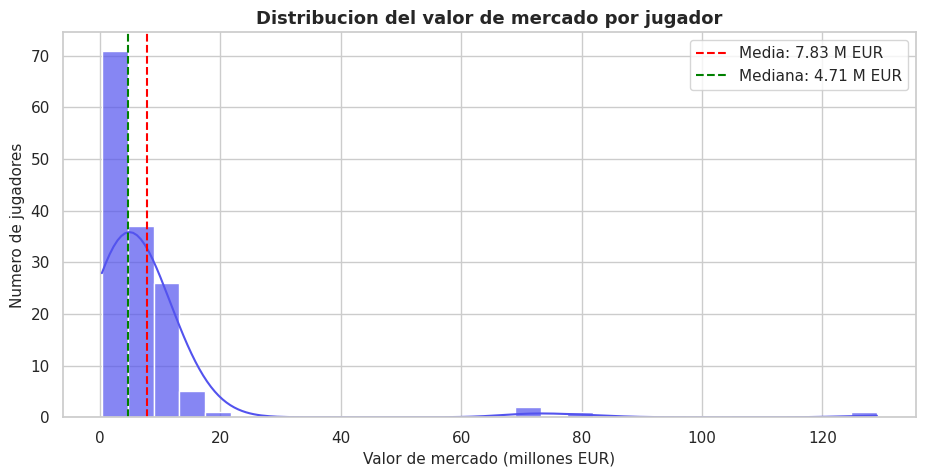

In [6]:
plt.figure(figsize=(11, 5))
sns.histplot(data=df, x="Valor_Mercado_Millones_EUR", bins=30, kde=True, color="#5353EE", alpha=0.7)
plt.title("Distribucion del valor de mercado por jugador")
plt.xlabel("Valor de mercado (millones EUR)")
plt.ylabel("Numero de jugadores")
plt.axvline(df["Valor_Mercado_Millones_EUR"].mean(), color="red", linestyle="--",
            label=f"Media: {df['Valor_Mercado_Millones_EUR'].mean():,.2f} M EUR")
plt.axvline(df["Valor_Mercado_Millones_EUR"].median(), color="green", linestyle="--",
            label=f"Mediana: {df['Valor_Mercado_Millones_EUR'].median():,.2f} M EUR")
plt.legend()
plt.show()

#### Como leer este grafico?

- El eje X son los rangos de valor de mercado (en millones de EUR).
- El eje Y es la frecuencia (cuantos jugadores caen en cada rango).
- La curva (KDE) muestra la forma general de la distribucion.
- La linea roja es la media (promedio) y la verde es la mediana.

#### Interpretacion

Cuando la media es mayor que la mediana, la distribucion esta sesgada a la derecha: hay una cola larga de valores altos que "jalan" el promedio hacia arriba. Esto es comun en valores de mercado deportivo: la mayoria de jugadores valen montos moderados y unas pocas estrellas concentran valores muy altos.

> **Consecuencia practica:** en distribuciones sesgadas, la mediana describe mejor el valor tipico que la media.

### 3.2 Multiples distribuciones a la vez

Cuando quieres comparar la forma de varias variables numericas, un grid de histogramas es la forma mas eficiente.

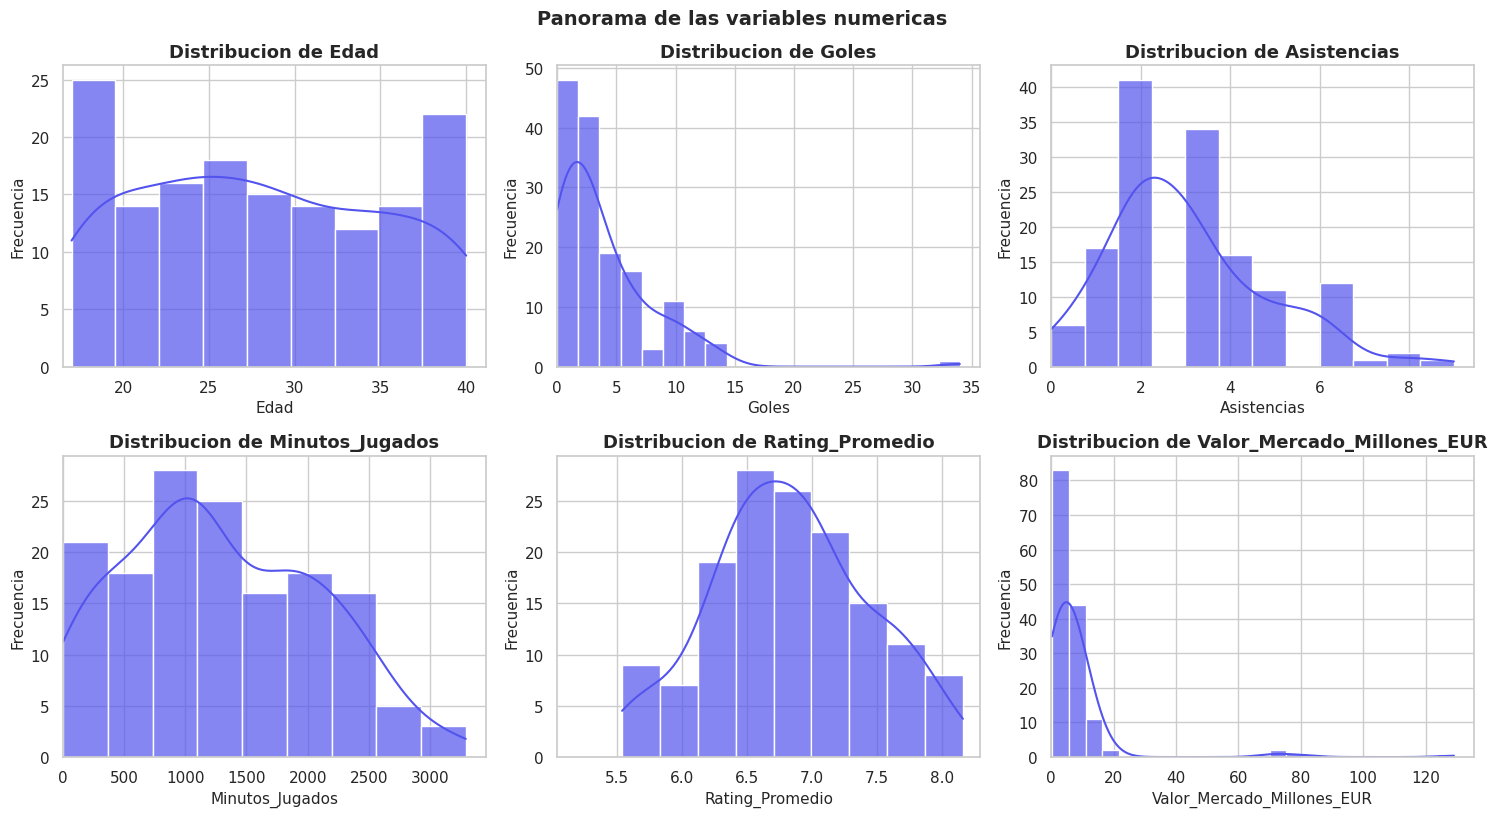

In [7]:
variables_num = ["Edad", "Goles", "Asistencias", "Minutos_Jugados", "Rating_Promedio", "Valor_Mercado_Millones_EUR"]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, var in enumerate(variables_num):
    sns.histplot(data=df, x=var, kde=True, ax=axes[i], color="#5353EE", alpha=0.7)
    axes[i].set_title(f"Distribucion de {var}")
    axes[i].set_ylabel("Frecuencia")
    axes[i].set_xlim(left=max(0, df[var].min() - 0.5))

plt.tight_layout()
plt.suptitle("Panorama de las variables numericas", y=1.02, fontsize=14, fontweight="bold")
plt.show()

#### Lectura del panorama

- `Goles`, `Asistencias` y `Edad` son discretas (valores enteros): sus "histogramas" se ven como barras separadas.
- `Minutos_Jugados` es discreta pero con muchos valores posibles, asi que se ve casi continua.
- `Rating_Promedio` y `Valor_Mercado_Millones_EUR` son continuas: sus formas nos dicen mucho mas sobre el proceso subyacente.

### 3.3 Boxplot: detectando outliers visualmente

El boxplot (diagrama de caja y bigotes) es la herramienta estandar para ver de un vistazo: mediana, cuartiles, rango tipico y valores atipicos (outliers).

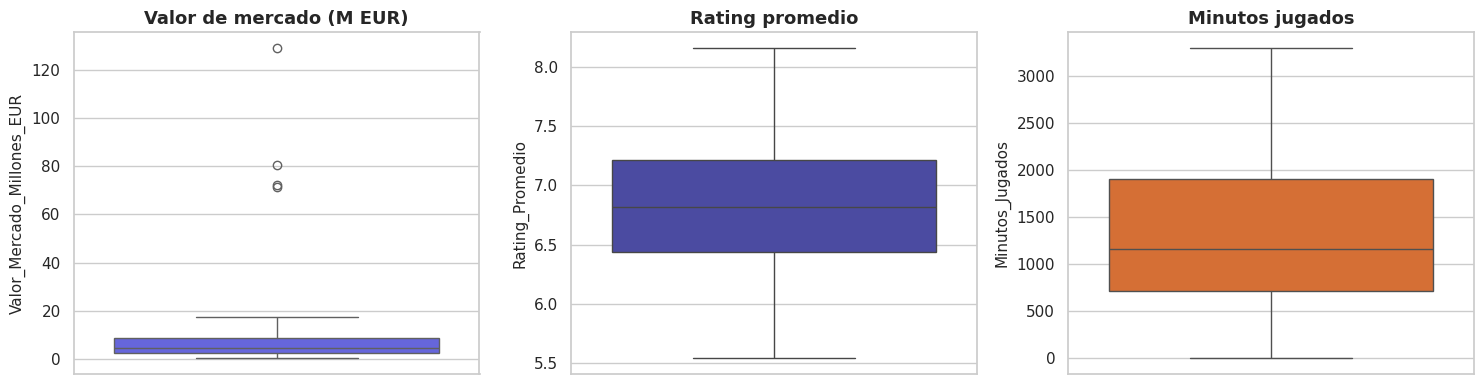

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.boxplot(data=df, y="Valor_Mercado_Millones_EUR", ax=axes[0], color="#5353EE")
axes[0].set_title("Valor de mercado (M EUR)")

sns.boxplot(data=df, y="Rating_Promedio", ax=axes[1], color="#3D3DAF")
axes[1].set_title("Rating promedio")

sns.boxplot(data=df, y="Minutos_Jugados", ax=axes[2], color="#F0681A")
axes[2].set_title("Minutos jugados")

plt.tight_layout()
plt.show()

#### Como leer un boxplot?

- La caja contiene el 50% central de los datos (del Q1 al Q3).
- La linea dentro de la caja es la mediana.
- Los bigotes se extienden hasta 1.5 veces el rango intercuartilico (IQR).
- Los puntos sueltos son outliers segun ese criterio.

#### Interpretacion

- `Valor_Mercado_Millones_EUR` tiene outliers hacia arriba: unos pocos jugadores (probablemente estrellas) valen mucho mas que el resto.
- `Rating_Promedio` se ve mas contenido, lo que sugiere que el desempeno esta relativamente parejo entre jugadores.
- `Minutos_Jugados` tiene bastante dispersion, coherente con que hay titulares y suplentes.

### 3.4 Medidas de forma: asimetria y curtosis

Un histograma es ilustrativo, pero necesitamos numeros para describir la forma de una distribucion. Dos medidas clave:

- **Asimetria (skewness):**
  - `= 0` -> distribucion simetrica.
  - `> 0` -> cola larga hacia la derecha (valores altos).
  - `< 0` -> cola larga hacia la izquierda.
- **Curtosis (kurtosis):**
  - `= 0` -> forma similar a la normal.
  - `> 0` -> distribucion "picuda" con colas pesadas.
  - `< 0` -> distribucion "aplanada".

In [9]:
# Calculamos asimetria y curtosis para las variables numericas
resumen_forma = pd.DataFrame({
    "Media":     df[variables_num].mean().round(2),
    "Mediana":   df[variables_num].median().round(2),
    "Std":       df[variables_num].std().round(2),
    "Asimetria": df[variables_num].skew().round(2),
    "Curtosis":  df[variables_num].kurtosis().round(2),
})

resumen_forma

,Media,Mediana,Std,Asimetria,Curtosis
Edad,28.05,28.00,7.27,0.12,-1.19
Goles,3.94,3.00,4.34,2.77,14.51
Asistencias,3.01,3.00,1.76,0.81,0.64
Minutos_Jugados,1283.95,1157.00,796.46,0.28,-0.75
Rating_Promedio,6.83,6.82,0.60,0.05,-0.45
Valor_Mercado_Millones_EUR,7.83,4.71,14.73,5.95,39.93


#### Pregunta para discutir en grupo

Mira la columna Asimetria. Que variable tiene la mayor asimetria positiva? Que te dice eso sobre el mercado de fichajes que genera esos datos?

---
## 4. Analisis univariado categorico

Para variables categoricas (texto, etiquetas), el histograma no aplica. Usamos countplots (graficos de conteo) y analisis de proporciones.

Las variables categoricas de nuestro dataset son: `Posicion`, `Equipo`, `Nacionalidad`.

### 4.1 Distribucion de categorias principales

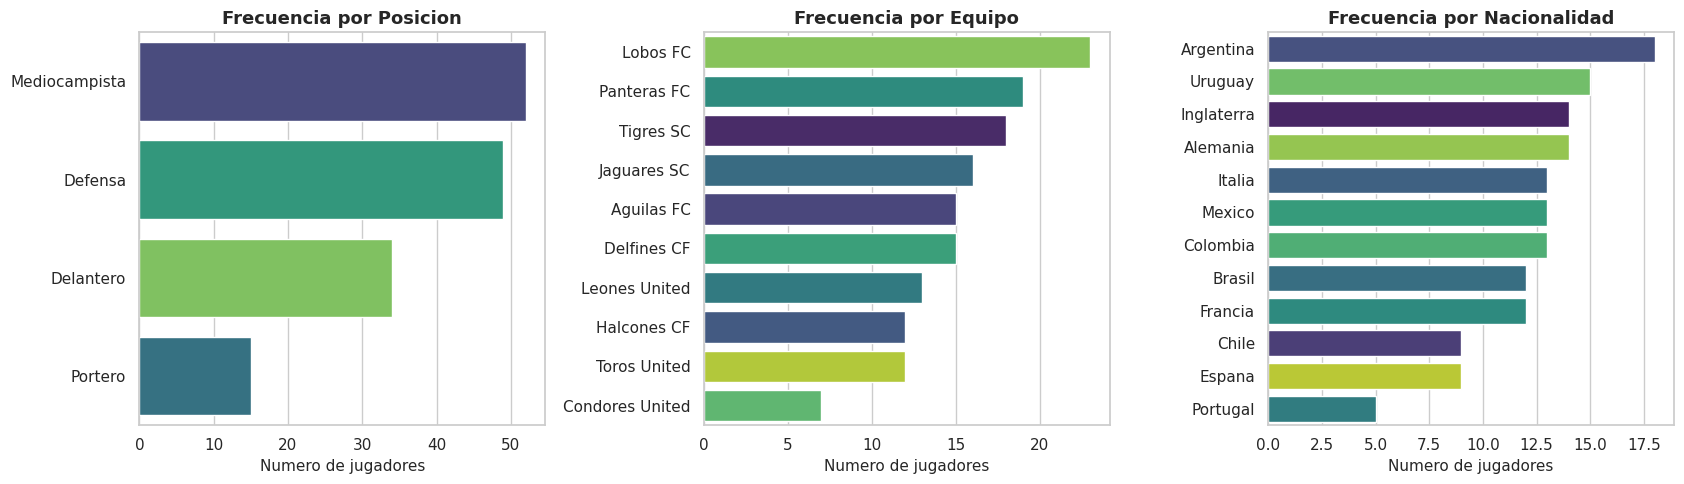

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

for ax, var in zip(axes, ["Posicion", "Equipo", "Nacionalidad"]):
    orden = df[var].value_counts().index
    sns.countplot(data=df, y=var, order=orden, ax=ax, palette="viridis", hue=var, legend=False)
    ax.set_title(f"Frecuencia por {var}")
    ax.set_xlabel("Numero de jugadores")
    ax.set_ylabel("")

plt.tight_layout()
plt.show()

#### Interpretacion

Cuando graficamos categoricas con `y=` (barras horizontales), las etiquetas se leen mejor y podemos comparar visualmente la altura relativa de cada categoria. Al ordenar de mayor a menor, obtenemos casi un diagrama de Pareto: identificamos rapidamente las categorias dominantes.

### 4.2 Hay desbalance en las posiciones?

Esta pregunta es importante porque un desbalance alto de posiciones puede afectar la representatividad del analisis por posicion.

In [11]:
# Frecuencia absoluta y relativa
tabla_posicion = pd.DataFrame({
    "Cantidad":  df["Posicion"].value_counts(),
    "Proporcion (%)": (df["Posicion"].value_counts(normalize=True) * 100).round(1),
})
tabla_posicion

,Cantidad,Proporcion (%)
Posicion,,
Mediocampista,52,34.7
Defensa,49,32.7
Delantero,34,22.7
Portero,15,10.0


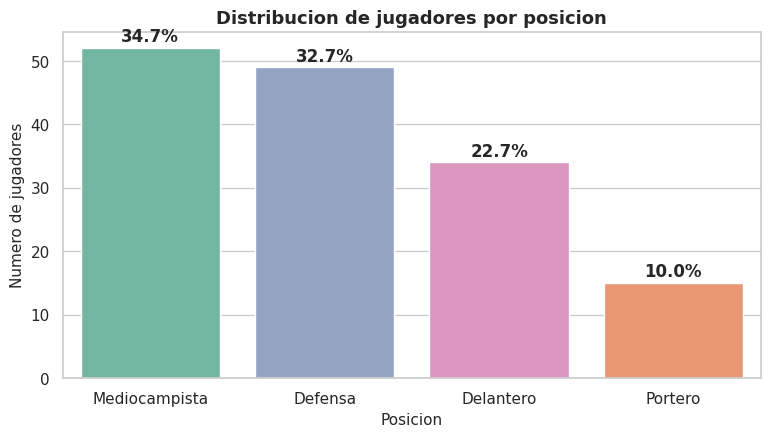

In [12]:
plt.figure(figsize=(9, 4.5))
orden_posicion = df["Posicion"].value_counts().index
sns.countplot(data=df, x="Posicion", order=orden_posicion, palette="Set2", hue="Posicion", legend=False)
plt.title("Distribucion de jugadores por posicion")
plt.xlabel("Posicion")
plt.ylabel("Numero de jugadores")

# Anotar el porcentaje encima de cada barra
total = len(df)
for i, posicion in enumerate(orden_posicion):
    conteo = (df["Posicion"] == posicion).sum()
    pct = conteo / total * 100
    plt.text(i, conteo + 1, f"{pct:.1f}%", ha="center", fontweight="bold")

plt.show()

#### Interpretacion

Si observamos que una posicion concentra un porcentaje muy alto o muy bajo de la plantilla, conviene tenerlo en cuenta antes de comparar promedios entre posiciones: pocas observaciones hacen que un promedio sea menos confiable.

---
## 5. Analisis bivariado: categorica vs numerica

Ahora combinamos una variable categorica con una numerica. Esto nos permite responder preguntas como:

- El valor de mercado total cambia segun el equipo?
- Hay posiciones con rating mas alto que otras?
- Los minutos jugados dependen del rating del jugador?

### 5.1 Valor de mercado total por equipo

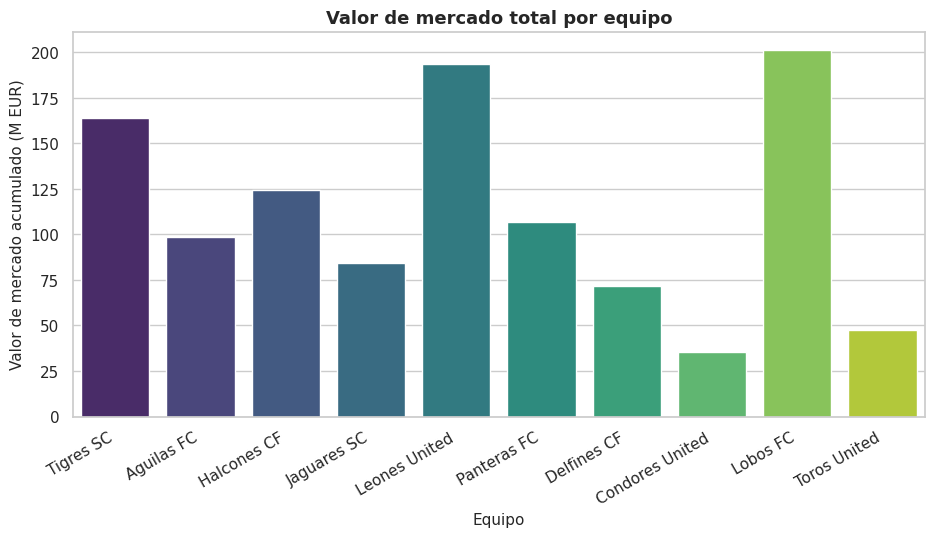

In [13]:
plt.figure(figsize=(11, 5))
sns.barplot(
    data=df, x="Equipo", y="Valor_Mercado_Millones_EUR",
    estimator="sum", errorbar=None,
    palette="viridis", hue="Equipo", legend=False
)
plt.title("Valor de mercado total por equipo")
plt.xlabel("Equipo")
plt.ylabel("Valor de mercado acumulado (M EUR)")
plt.xticks(rotation=30, ha="right")
plt.show()

> **Nota tecnica:** usamos `estimator="sum"` para agregar (sumar el valor de mercado por equipo). Si no lo especificamos, seaborn usa la media por defecto. Ademas, `errorbar=None` desactiva las barras de error.

### 5.2 Distribucion del rating por posicion

Un barplot resume informacion con un solo numero por categoria. Un boxplot condicionado muestra la distribucion completa, lo cual es mucho mas informativo.

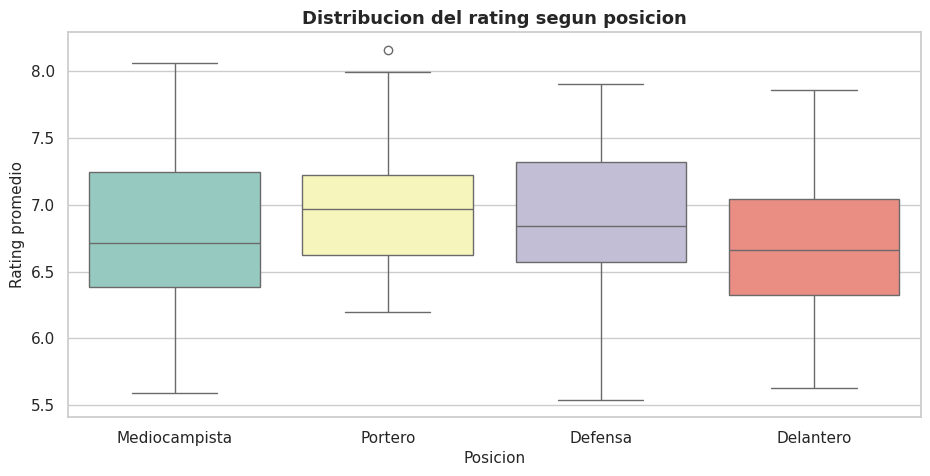

In [14]:
plt.figure(figsize=(11, 5))
sns.boxplot(data=df, x="Posicion", y="Rating_Promedio", palette="Set3", hue="Posicion", legend=False)
plt.title("Distribucion del rating segun posicion")
plt.xlabel("Posicion")
plt.ylabel("Rating promedio")
plt.show()

#### Lectura clave

Si alguna posicion tiene medianas de rating claramente mas altas o mas bajas, eso sugiere que el rol en cancha influye en como se califica el desempeno.

### 5.3 Minutos jugados segun nivel de rating

Hipotesis: los jugadores mejor calificados (rating mas alto) juegan mas minutos. Para probarla, agrupamos el rating en categorias y comparamos minutos jugados.

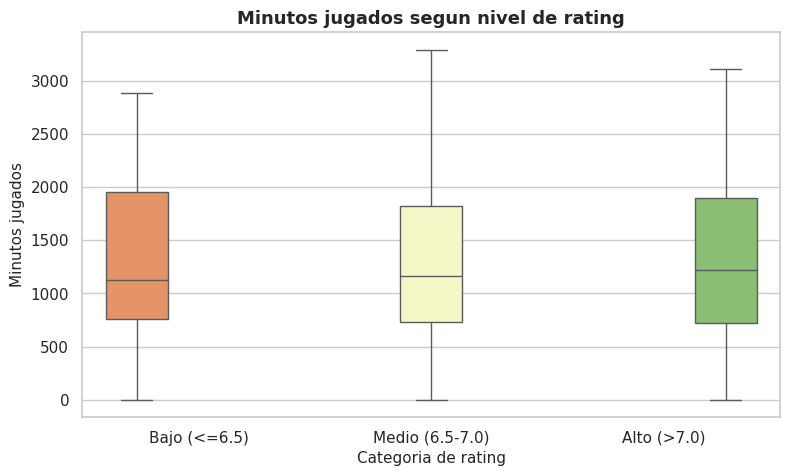

In [15]:
df["rating_categoria"] = pd.cut(
    df["Rating_Promedio"],
    bins=[0, 6.5, 7.0, 10],
    labels=["Bajo (<=6.5)", "Medio (6.5-7.0)", "Alto (>7.0)"]
)

plt.figure(figsize=(9, 5))
sns.boxplot(
    data=df, x="rating_categoria", y="Minutos_Jugados",
    palette="RdYlGn",
    hue="rating_categoria",
    legend=False,
)
plt.title("Minutos jugados segun nivel de rating")
plt.xlabel("Categoria de rating")
plt.ylabel("Minutos jugados")
plt.show()

#### Discusion

Se confirma la hipotesis? Si vemos que la categoria de rating alto tiene medianas de minutos mas altas, hay evidencia visual del patron. Pero cuidado: correlacion visual no es causalidad.

---
## 6. Analisis bivariado: categorica vs categorica

Cuando cruzamos dos categoricas, la herramienta reina es la tabla de contingencia (`pd.crosstab`) visualizada como heatmap.

### 6.1 Que posiciones tiene cada equipo?

In [16]:
tabla = pd.crosstab(df["Equipo"], df["Posicion"])
tabla

Posicion,Defensa,Delantero,Mediocampista,Portero
Equipo,,,,
Aguilas FC,5,4,4,2
Condores United,2,2,1,2
Delfines CF,4,3,7,1
Halcones CF,5,2,4,1
Jaguares SC,5,4,7,0
Leones United,6,2,4,1
Lobos FC,5,6,9,3
Panteras FC,9,4,5,1
Tigres SC,5,4,7,2


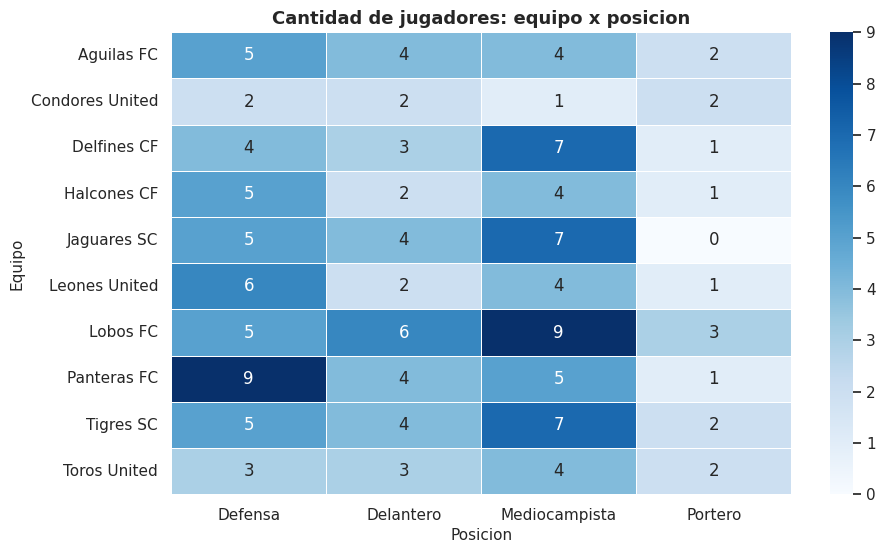

In [17]:
plt.figure(figsize=(10, 6))
sns.heatmap(tabla, annot=True, fmt="d", cmap="Blues", linewidths=0.5)
plt.title("Cantidad de jugadores: equipo x posicion")
plt.xlabel("Posicion")
plt.ylabel("Equipo")
plt.show()

### 6.2 Proporciones dentro de cada equipo

A veces los conteos absolutos enganan (un equipo con mas jugadores domina el color). Es mas util ver que proporcion representa cada posicion dentro de su equipo.

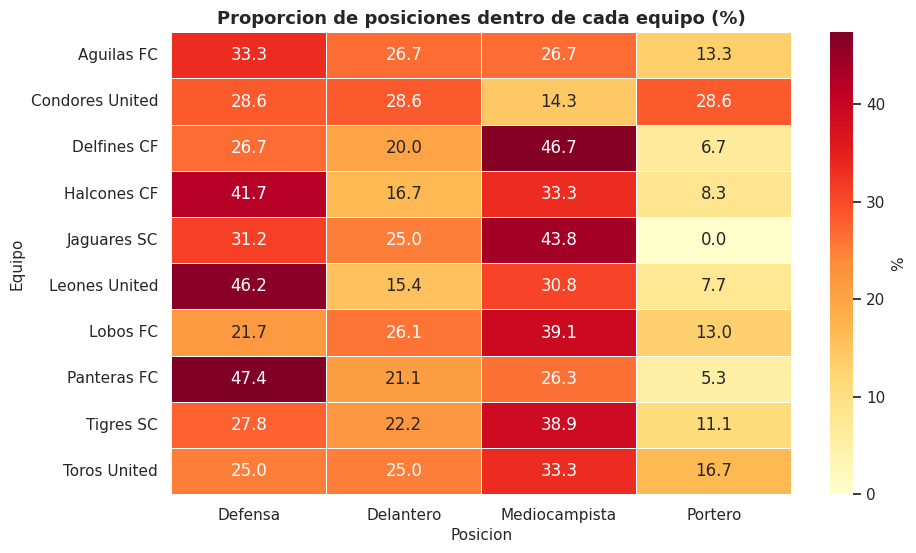

In [18]:
# Normalizamos por fila (cada equipo suma 100%)
tabla_prop = pd.crosstab(df["Equipo"], df["Posicion"], normalize="index") * 100

plt.figure(figsize=(10, 6))
sns.heatmap(tabla_prop, annot=True, fmt=".1f", cmap="YlOrRd", linewidths=0.5, cbar_kws={"label": "%"})
plt.title("Proporcion de posiciones dentro de cada equipo (%)")
plt.xlabel("Posicion")
plt.ylabel("Equipo")
plt.show()

#### Insight

Este segundo heatmap responde una pregunta distinta al primero: que composicion tactica tiene cada equipo? Un equipo puede tener pocos jugadores en total pero una mezcla de posiciones muy particular.

---
## 7. Analisis multivariado: mapa de correlaciones

Cuando queremos entender como se mueven juntas varias variables numericas al tiempo, la herramienta clave es la matriz de correlacion, visualizada como un heatmap.

### 7.1 Que es la correlacion?

La correlacion de Pearson (r) mide la fuerza y direccion de una relacion lineal entre dos variables numericas:

| Valor de r | Interpretacion |
|-----------|----------------|
| `r = +1`  | Correlacion positiva perfecta |
| `r ~ +0.7 a +0.9` | Correlacion positiva fuerte |
| `r ~ +0.3 a +0.6` | Correlacion positiva moderada |
| `r ~ 0`   | Sin relacion lineal |
| `r ~ -0.3 a -0.6` | Correlacion negativa moderada |
| `r = -1`  | Correlacion negativa perfecta |

> **Importante:** correlacion NO es causalidad. Y la correlacion de Pearson solo captura relaciones lineales.

In [19]:
# Seleccionamos las variables numericas
variables_corr = ["Edad", "Partidos_Jugados", "Goles", "Asistencias",
                  "Minutos_Jugados", "Tarjetas_Amarillas", "Tarjetas_Rojas",
                  "Altura_cm", "Peso_kg", "Rating_Promedio", "Valor_Mercado_Millones_EUR"]

matriz_corr = df[variables_corr].corr(method="pearson")
matriz_corr.round(2)

,Edad,Partidos_Jugados,Goles,Asistencias,Minutos_Jugados,Tarjetas_Amarillas,Tarjetas_Rojas,Altura_cm,Peso_kg,Rating_Promedio,Valor_Mercado_Millones_EUR
Edad,1.00,-0.02,-0.15,-0.10,-0.01,-0.02,0.04,-0.02,0.03,0.05,-0.15
Partidos_Jugados,-0.02,1.00,-0.03,-0.03,0.89,-0.01,0.09,-0.01,-0.03,-0.01,0.05
Goles,-0.15,-0.03,1.00,0.32,0.02,-0.06,0.01,0.09,-0.08,-0.13,0.60
Asistencias,-0.10,-0.03,0.32,1.00,-0.03,0.06,-0.04,-0.12,0.06,0.05,0.25
Minutos_Jugados,-0.01,0.89,0.02,-0.03,1.00,-0.02,0.05,-0.08,-0.02,-0.05,0.10
Tarjetas_Amarillas,-0.02,-0.01,-0.06,0.06,-0.02,1.00,-0.02,0.13,0.12,-0.10,-0.06
Tarjetas_Rojas,0.04,0.09,0.01,-0.04,0.05,-0.02,1.00,-0.09,-0.06,0.04,-0.00
Altura_cm,-0.02,-0.01,0.09,-0.12,-0.08,0.13,-0.09,1.00,0.09,0.01,-0.02
Peso_kg,0.03,-0.03,-0.08,0.06,-0.02,0.12,-0.06,0.09,1.00,0.06,0.06
Rating_Promedio,0.05,-0.01,-0.13,0.05,-0.05,-0.10,0.04,0.01,0.06,1.00,-0.12


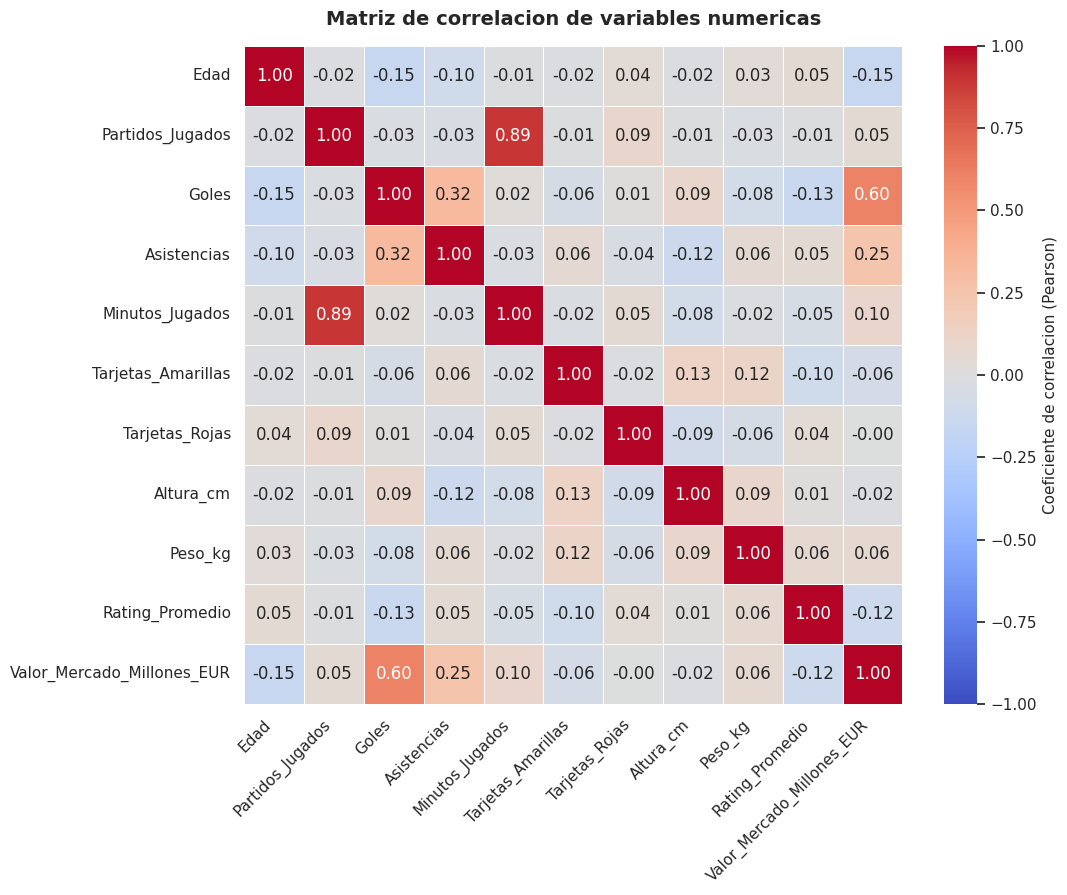

In [20]:
plt.figure(figsize=(11, 9))
sns.heatmap(
    matriz_corr,
    annot=True,
    cmap="coolwarm",
    center=0,
    vmin=-1, vmax=1,
    fmt=".2f",
    linewidths=0.5,
    square=True,
    cbar_kws={"label": "Coeficiente de correlacion (Pearson)"},
)
plt.title("Matriz de correlacion de variables numericas", fontsize=14, pad=15)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

#### Como leer este mapa

- Rojos intensos -> correlacion positiva fuerte.
- Azules intensos -> correlacion negativa fuerte.
- Blanco/palido -> sin correlacion lineal apreciable.
- La diagonal siempre es 1.
- La matriz es simetrica: `corr(A, B) = corr(B, A)`.

#### Interpretaciones esperables

- `Minutos_Jugados` <-> `Partidos_Jugados`: correlacion positiva fuerte (a mas partidos, mas minutos).
- `Goles` <-> `Valor_Mercado_Millones_EUR`: si es positiva, confirma que anotar goles se traduce en mayor valor de mercado.
- `Edad` <-> `Valor_Mercado_Millones_EUR`: la relacion puede ser negativa despues de cierta edad (jugadores mayores pierden valor).
- `Altura_cm` <-> `Peso_kg`: correlacion positiva esperable por razones fisiologicas.

#### Pregunta para discutir

Observa la celda `Goles` x `Valor_Mercado_Millones_EUR`. Que tan fuerte es esa relacion? Que implica esto sobre como el mercado valora a los jugadores?

### 7.2 Scatter plot para los pares mas correlacionados

El heatmap nos dice cuanto estan correlacionadas dos variables. El scatter plot nos muestra como estan relacionadas: la forma exacta de la nube de puntos.

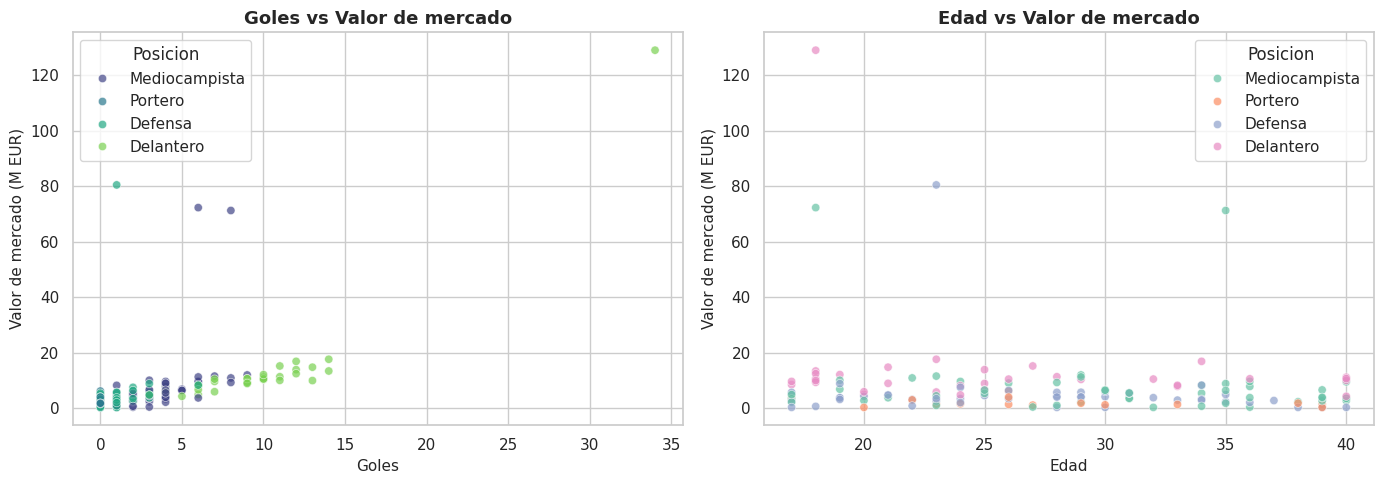

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter 1: Goles vs Valor_Mercado_Millones_EUR
sns.scatterplot(
    data=df, x="Goles", y="Valor_Mercado_Millones_EUR",
    hue="Posicion", alpha=0.7, ax=axes[0], palette="viridis"
)
axes[0].set_title("Goles vs Valor de mercado")
axes[0].set_xlabel("Goles")
axes[0].set_ylabel("Valor de mercado (M EUR)")

# Scatter 2: Edad vs Valor_Mercado_Millones_EUR
sns.scatterplot(
    data=df, x="Edad", y="Valor_Mercado_Millones_EUR",
    hue="Posicion", alpha=0.7, ax=axes[1], palette="Set2"
)
axes[1].set_title("Edad vs Valor de mercado")
axes[1].set_xlabel("Edad")
axes[1].set_ylabel("Valor de mercado (M EUR)")

plt.tight_layout()
plt.show()

#### El poder del `hue`

Cuando le agregamos `hue=` a un scatter plot, cada punto se colorea segun una tercera variable categorica. Esto convierte un analisis bivariado en trivariado con muy poco esfuerzo.

---
## 8. Analisis por rango de edad

El dataset no tiene una dimension temporal (fechas), pero la edad funciona como una progresion natural de carrera. Ver la evolucion por rango de edad revela patrones que un analisis estatico no puede detectar.

### 8.1 Rating promedio segun rango de edad

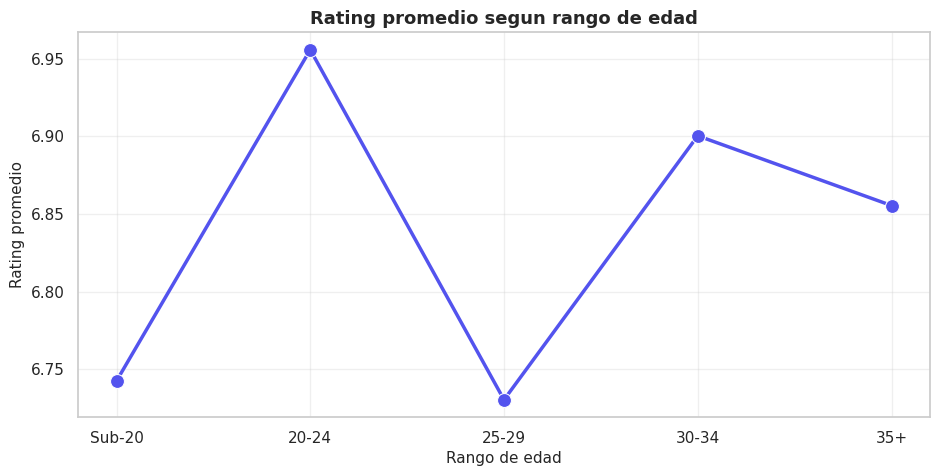

In [22]:
rating_por_edad = df.groupby("rango_edad", observed=True)["Rating_Promedio"].mean().reset_index()

plt.figure(figsize=(11, 5))
sns.lineplot(data=rating_por_edad, x="rango_edad", y="Rating_Promedio",
             marker="o", linewidth=2.5, color="#5353EE", markersize=10, sort=False)
plt.title("Rating promedio segun rango de edad")
plt.xlabel("Rango de edad")
plt.ylabel("Rating promedio")
plt.grid(True, alpha=0.3)
plt.show()

### 8.2 Valor de mercado promedio por rango de edad

Es de esperar que el valor de mercado suba en la etapa media de la carrera y baje hacia el final.

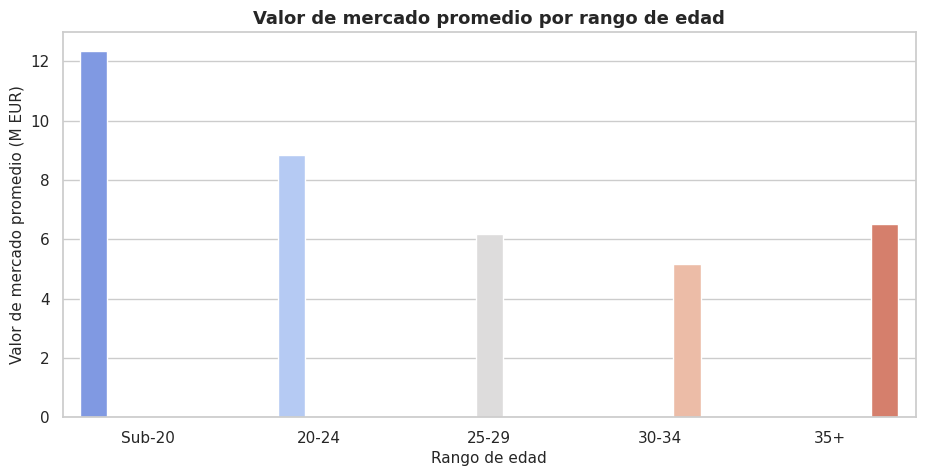

In [23]:
plt.figure(figsize=(11, 5))
sns.barplot(
    data=df, x="rango_edad", y="Valor_Mercado_Millones_EUR",
    estimator="mean", errorbar=None,
    palette="coolwarm", hue="rango_edad", legend=False,
)
plt.title("Valor de mercado promedio por rango de edad")
plt.xlabel("Rango de edad")
plt.ylabel("Valor de mercado promedio (M EUR)")
plt.show()

### 8.3 Comparacion por rango de edad y posicion

Cruzamos rango de edad + posicion con un unico grafico usando `hue=`.

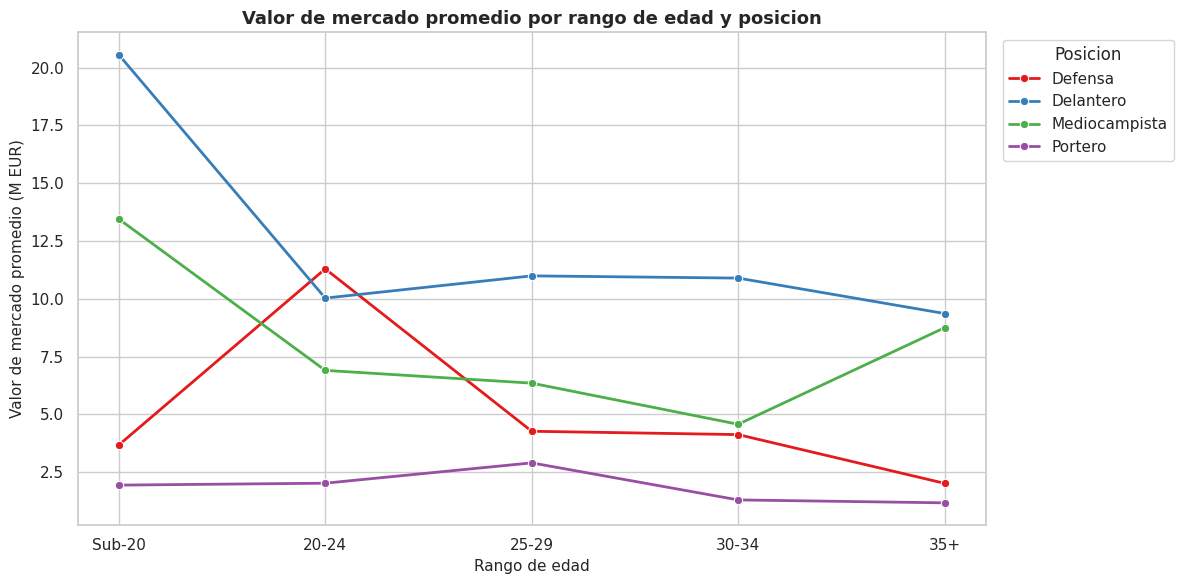

In [24]:
valor_edad_posicion = df.groupby(["rango_edad", "Posicion"], observed=True)["Valor_Mercado_Millones_EUR"].mean().reset_index()

plt.figure(figsize=(12, 6))
sns.lineplot(
    data=valor_edad_posicion, x="rango_edad", y="Valor_Mercado_Millones_EUR",
    hue="Posicion", marker="o", linewidth=2, palette="Set1", sort=False
)
plt.title("Valor de mercado promedio por rango de edad y posicion")
plt.xlabel("Rango de edad")
plt.ylabel("Valor de mercado promedio (M EUR)")
plt.legend(title="Posicion", loc="upper left", bbox_to_anchor=(1.01, 1))
plt.tight_layout()
plt.show()

#### Lectura

Un grafico asi permite ver si todas las posiciones pierden o ganan valor al mismo ritmo con la edad (patron general) o si alguna posicion se comporta distinto (por ejemplo, porteros que suelen tener carreras mas largas).

---
## 9. Sintesis de hallazgos

Un buen analista no se queda en los graficos. El paso final del EDA es traducir lo visto en insights accionables.

### Plantilla de hallazgos

Con base en todo lo explorado, completa la siguiente tabla como equipo:

| # | Hallazgo (que vimos) | Evidencia (que grafico lo muestra) | Implicacion |
|---|----------------------|-------------------------------------|-------------|
| 1 | *Ej: El equipo X concentra el mayor valor de mercado* | Sec 5.1 | Enfocar la estrategia de renovaciones en X |
| 2 | | | |
| 3 | | | |
| 4 | | | |
| 5 | | | |

### Buenas practicas de comunicacion

- Se especifico: "el valor de mercado promedio cae 20% despues de los 30 anios" es mejor que "hay una caida".
- Muestra el grafico que soporta el insight.
- Separa hechos de hipotesis: "vemos X" (hecho) vs "creemos que se debe a Y" (hipotesis a validar).
- Termina con una recomendacion accionable.

---
# Reto final - Tu turno

Ahora ustedes son los analistas. Respondan las siguientes preguntas con codigo + grafico + interpretacion escrita en las celdas de abajo. Cada respuesta debe tener:

1. Una celda de codigo con el analisis/grafico.
2. Una celda de markdown con la interpretacion (2-3 lineas).

### Preguntas

**Reto 1 - Jugador mas valioso.**
Cuales son los 5 jugadores con mayor valor de mercado? Graficalo como barras horizontales ordenadas.

**Reto 2 - Edad vs partidos jugados.**
Los jugadores de mayor edad juegan menos partidos? Usa un boxplot condicionado (por rango de edad) o un scatter plot para responderlo.

**Reto 3 - Equipo mas valioso.**
Calcula el valor de mercado promedio por equipo y graficalo. Cual equipo tiene el promedio mas alto? Y el mas bajo?

**Reto 4 - Analisis multivariado con `pairplot`.**
Usa `sns.pairplot(df, vars=["Goles", "Asistencias", "Minutos_Jugados", "Rating_Promedio"], hue="Posicion")` y responde: alguna posicion se ve claramente diferenciada?

**Reto 5 - Alerta disciplinaria.**
Genera una tabla que muestre, para cada equipo, el porcentaje de jugadores con al menos una tarjeta roja. Hay algun equipo con problemas disciplinarios?

**Reto 6 - Reporte ejecutivo (redaccion).**
Escribe un parrafo de maximo 200 palabras dirigido al Director Deportivo, con 3 recomendaciones concretas basadas en TODO el analisis (secciones 3 a 8 + tus retos). El director no sabe de estadistica: hablale en lenguaje de futbol y negocio.

---

### Cierre

> "Los datos no hablan solos. Un buen analisis exploratorio es una conversacion entre tus preguntas y lo que los datos son capaces de contarte."


### Reto 1

In [25]:
# Tu codigo aqui para el Reto 1


_Tu interpretacion aqui_

### Reto 2

In [26]:
# Tu codigo aqui para el Reto 2


_Tu interpretacion aqui_

### Reto 3

In [27]:
# Tu codigo aqui para el Reto 3


_Tu interpretacion aqui_

### Reto 4

In [28]:
# Tu codigo aqui para el Reto 4


_Tu interpretacion aqui_

### Reto 5

In [29]:
# Tu codigo aqui para el Reto 5


_Tu interpretacion aqui_

### Reto 6

In [30]:
# Tu codigo aqui para el Reto 6


_Tu interpretacion aqui_